In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [246]:
# Lee el archivo normalmente
df = pd.read_csv("afluencia_metro_cdmx.csv", encoding='utf-8')

# Reemplazo manual de los caracteres problemáticos (completo)
replacements = {
    'Ã¡': 'á',
    'Ã©': 'é', 
    'Ã­': 'í',  
    'Ã³': 'ó',
    'Ãº': 'ú',
    'Ã±': 'ñ',
}

# Aplica los reemplazos en las columnas de texto
for col in df.select_dtypes(include=['object']).columns:
    for old, new in replacements.items():
        df[col] = df[col].astype(str).str.replace(old, new, regex=False)

In [247]:
df.head(20)

,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la Católica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino Suárez,8679
4,2010-01-01,2010,Enero,Linea 1,Gómez Farías,19499
5,2010-01-01,2010,Enero,Linea 6,Deportivo 18 de Marzo,621
6,2010-01-01,2010,Enero,Linea 6,La Villa/Basílica,24792
7,2010-01-01,2010,Enero,Linea 9,Pantitlán,27000
8,2010-01-01,2010,Enero,Linea 8,Aculco,3652
9,2010-01-01,2010,Enero,Linea 9,Velódromo,3239


In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1162980 entries, 0 to 1162979
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   fecha      1162980 non-null  object
 1   anio       1162980 non-null  int64 
 2   mes        1162980 non-null  object
 3   linea      1162980 non-null  object
 4   estacion   1162980 non-null  object
 5   afluencia  1162980 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 53.2+ MB


In [249]:
# ----- Tamaño del Data Frame -----
print(f"El Data Frame tiene {df.shape[0]:,.2f} filas")
print(f"El Data Frame tiene {df.shape[1]:.0f} columnas")

El Data Frame tiene 1,162,980.00 filas
El Data Frame tiene 6 columnas


In [250]:
df["linea"].value_counts()

linea
Linea 2     121992
Linea 3     106743
Linea B     106743
Linea 1     101660
Linea 12    101660
Linea 8      96577
Linea 7      71162
Linea 5      66079
Linea 9      60996
Linea 6      55913
Linea 4      50830
Linea A      50830
Línea 2      21144
Línea 3      18501
Línea B      18501
Línea 12     17620
Línea 1      17620
Línea 8      16739
Línea 7      12334
Línea 5      11453
Línea 9      10572
Línea 6       9691
Línea 4       8810
Línea A       8810
Name: count, dtype: int64

En este caso tenemos el problema de que algunas lineas del metro tienen acento y otras,están escritas de forma diferente:
* `"Linea 2"` (sin acento) = 121,992 registros
* `"Línea 2"` (con acento) = 21,144 registros

In [251]:
# ----- Quitamos el acento a las lineas que lo tienen para tener todos los nombres en orden -----
# Reemplazar "Línea" por "Linea" (quitar acentos)
df["linea"] = df["linea"].str.replace("Línea", "Linea", regex=False)

# Usamos "lower()" para estandarizar a minúsculas
df["linea"] = df["linea"].str.lower() # o str.upper()

# Mostramos los valores de la columna "linea" con los cambios
afluencia_doce_lineas = df["linea"].value_counts()
afluencia_doce_lineas

linea
linea 2     143136
linea 3     125244
linea b     125244
linea 1     119280
linea 12    119280
linea 8     113316
linea 7      83496
linea 5      77532
linea 9      71568
linea 6      65604
linea 4      59640
linea a      59640
Name: count, dtype: int64

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_2123/689853514.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=suma_numero_personas_linea.index,


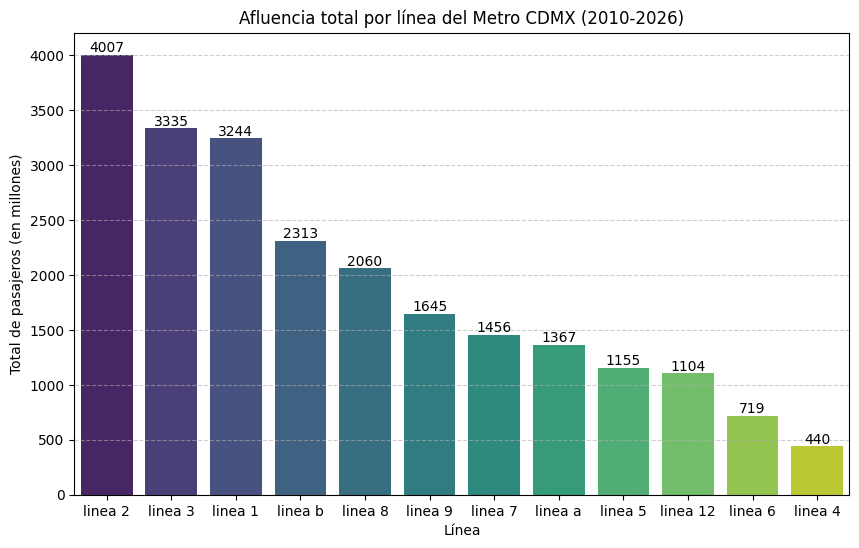

In [252]:
# ----- Graficamos el número de personas que utilizan una de las doce lineas del metro -----
# Esto SUMA la afluencia (número de personas)
suma_numero_personas_linea = df.groupby('linea')['afluencia'].sum().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(10,6))
barras = sns.barplot(x=suma_numero_personas_linea.index,
            y=suma_numero_personas_linea.values / 1_000_000,
            palette="viridis")
# Agregamos el número de personas en cada barra
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0f')
plt.title("Afluencia total por línea del Metro CDMX (2010-2026)")
plt.xlabel("Línea")
plt.ylabel('Total de pasajeros (en millones)')
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## ¿La distancia total / kilómetros de una línea está relacionada con la afluencia de usuarios?

Personalmente **considero** que sí, puesto que las líneas del metro con mayor longitud son:

1. **Línea 12 (Línea Dorada)**
   - Longitud: 25.1 km
   - Ruta: Mixcoac - Tláhuac
   - Estaciones: 20

2. **Línea B**
   - Longitud: 23.7 km
   - Ruta: Buenavista - Ciudad Azteca
   - Estaciones: 21

3. **Línea 3 (Línea Verde)**
   - Longitud: 23.6 km
   - Ruta: Universidad - Indios Verdes
   - Estaciones: 21

4. **Línea 2 (Línea Azul)**
   - Longitud: 23.4 km
   - Ruta: Tasqueña - Cuatro Caminos
   - Estaciones: 24 *(la línea con más estaciones de toda la red)*

**A excepción** de la Línea 12, las demás líneas (B, 3, 2) están en el top 5 de las más usadas y son de las más largas de la red. Considero que el hecho de que una línea tenga más de 20 km es de gran ayuda para muchos usuarios. 

Por ejemplo, la **Línea B** tiene la estación más alejada de la red (Ciudad Azteca) y cruza varios municipios del Estado de México como Nezahualcoyóotl, Ecatepec, Olmpica, Múzquiz, etc. Teniendo en cuenta que diariamente entran aproximadamente **2.2 millones de personas** del Estado de México a la CDMX¹, las líneas que conectan estas dos metrópolis son de las más usadas.

El hecho de que la **Línea 12** no esté en el top 5 de las líneas más usadas, **a pesar** de ser la más larga, pienso que se debe a que sus estaciones no están en las alcaldías y zonas más céntricas de la CDMX. 

Por ejemplo, la alcaldía **Cuauhtémoc** —donde radican monumentos, oportunidades laborales, hospitales y avenidas populares— cuenta con 5 líneas del metro, y 3 de ellas están en el top 5 de las más usadas (B, 1 y 2). En cambio, alcaldías como **Tláhuac**, que no cuentan con esa densidad de servicios, provocan que los usuarios no tengan necesidad de usar la Línea 12 con tanta frecuencia.

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_2123/861273397.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=suma_numero_personas_linea_2019.index,


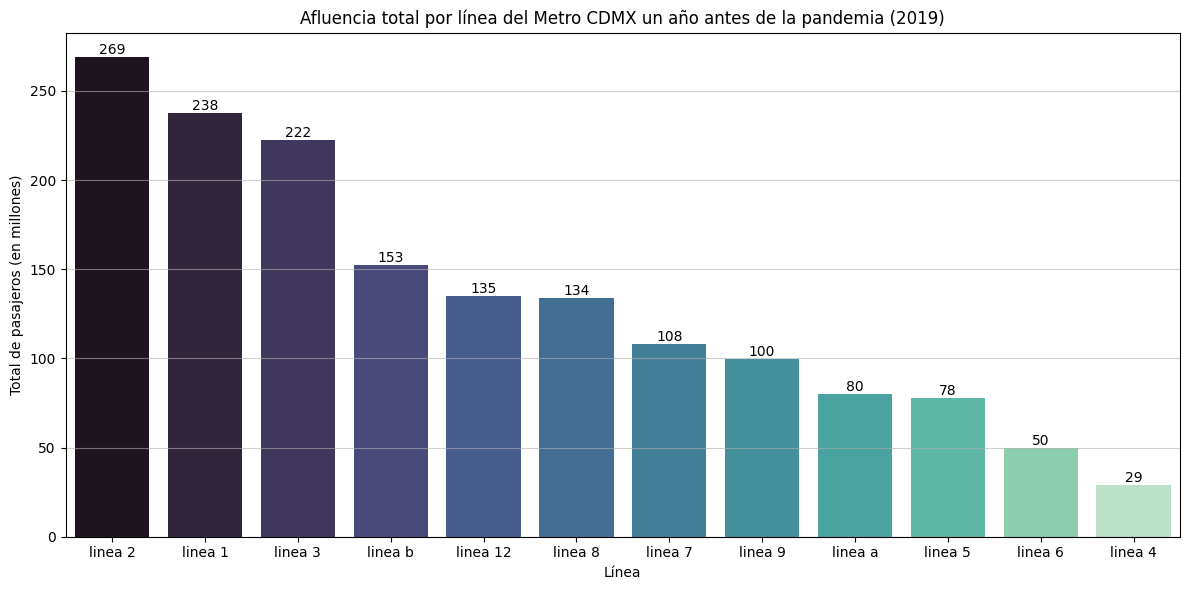

In [253]:
# ----- En el año 2019 (un año antes de la pandemia ¿que tal estaba la afluencia en cada una de las 12 línas del metro?)
# Creamos un Data Frame llamado "df_2019" para ver la fluencia de usuarios un año antes del encierro masivo
df_2019 = df[df["anio"] == 2019]

# Graficamos la fluencia total por línea del metro en el año 2019
#  Esto SUMA la afluencia (número de personas) en el año 2019
suma_numero_personas_linea_2019 = df_2019.groupby("linea")["afluencia"].sum().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Afluencia total por línea del Metro CDMX un año antes de la pandemia (2019)")
barras = sns.barplot(x=suma_numero_personas_linea_2019.index,
                     y=suma_numero_personas_linea_2019.values / 1_000_000,
                     palette="mako")
# Agregamos el número de usuarios en cada barra
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0f')
plt.xlabel("Línea")
plt.ylabel('Total de pasajeros (en millones)')
plt.grid(axis="y",
         linestyle="-",
         alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_2123/1788755901.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=suma_numero_personas_linea_2020.index,


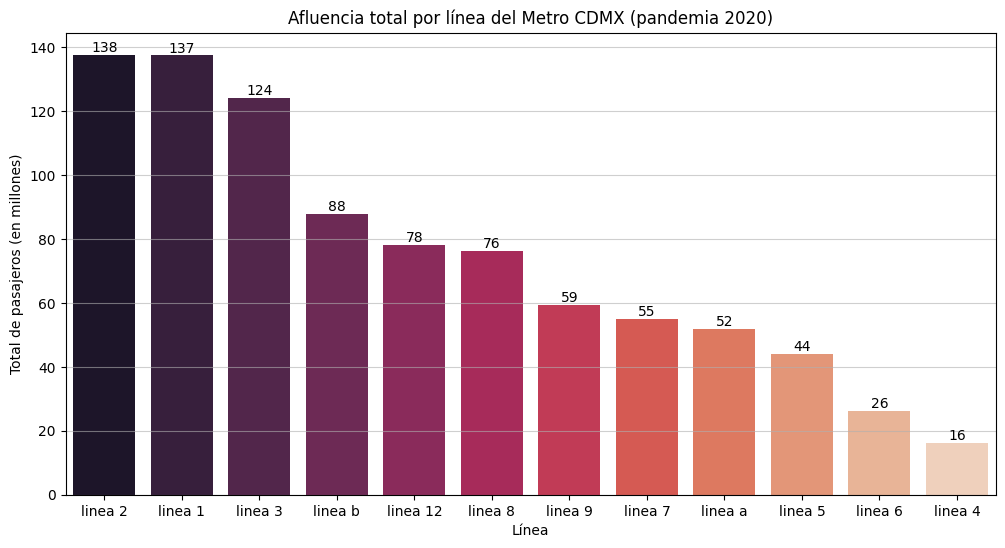

In [254]:
# ----- En el 2020 (año de la pandemia) ¿se dejó de usar el metro o únicamente la fluencia bajo exponencialmente? -----
# Creamos un Data Frame llamado "df_2020" para ver la fluencia de usuarios en ese polémico año
df_2020 = df[df["anio"] == 2020]

# Graficamos la fluencia total por línea del metro en el año 2020
#  Esto SUMA la afluencia (número de personas) en el año 2020
suma_numero_personas_linea_2020 = df_2020.groupby("linea")["afluencia"].sum().sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Afluencia total por línea del Metro CDMX (pandemia 2020)")
barras = sns.barplot(x=suma_numero_personas_linea_2020.index,
                     y=suma_numero_personas_linea_2020.values / 1_000_000,
                     palette="rocket")
# Agregamos el número de usuarios en cada barra
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0f')
plt.xlabel("Línea")
plt.ylabel('Total de pasajeros (en millones)')
plt.grid(axis="y",
         linestyle="-",
         alpha=0.6)
plt.show()

In [255]:
# Preparar datos para comparar
afluencia_2019 = df_2019.groupby("linea")["afluencia"].sum() / 1_000_000
afluencia_2020 = df_2020.groupby("linea")["afluencia"].sum() / 1_000_000

# Crear tabla comparativa
df_comparativa = pd.DataFrame({
    "2019 (millones)": afluencia_2019,
    "2020 (millones)": afluencia_2020
}).sort_values("2019 (millones)", ascending=False)

# Calcular caída porcentual
df_comparativa["Caída %"] = ((df_comparativa["2020 (millones)"] - df_comparativa["2019 (millones)"]) 
                             / df_comparativa["2019 (millones)"] * 100).round(1)

print("Caída de afluencia 2019 al 2020 por línea:")
print(df_comparativa)

Caída de afluencia 2019 al 2020 por línea:
          2019 (millones)  2020 (millones)  Caída %
linea                                              
linea 2        269.149446       137.704512    -48.8
linea 1        237.504859       137.479354    -42.1
linea 3        222.368257       124.140035    -44.2
linea b        152.545958        87.833699    -42.4
linea 12       134.900367        78.214776    -42.0
linea 8        133.620679        76.407157    -42.8
linea 7        108.152051        54.967994    -49.2
linea 9         99.592251        59.293773    -40.5
linea a         79.850830        51.956466    -34.9
linea 5         78.007727        44.037523    -43.5
linea 6         49.945822        26.086778    -47.8
linea 4         29.013032        16.102275    -44.5


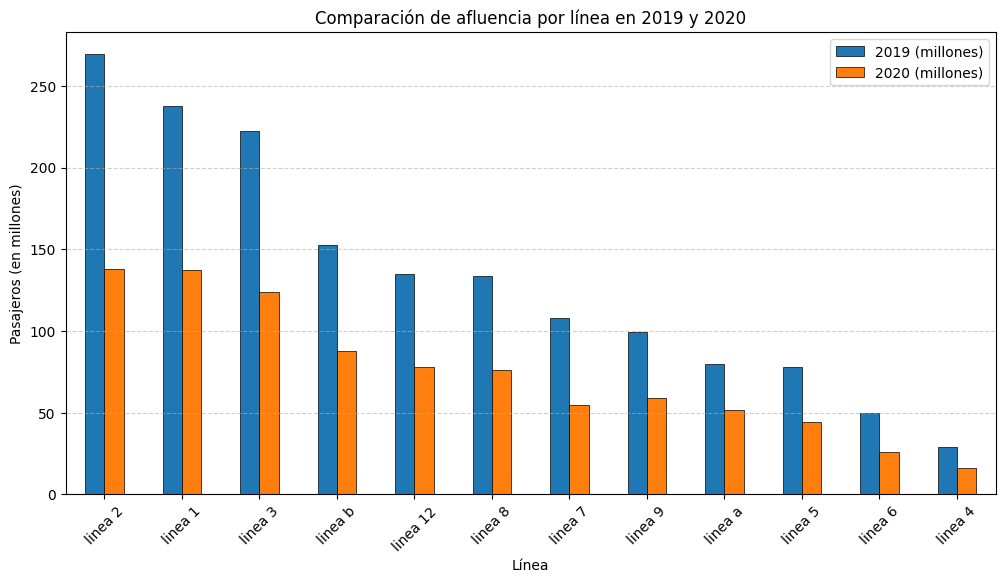

In [274]:
df_comparativa[["2019 (millones)", "2020 (millones)"]].plot(
    kind="bar",
    figsize=(12,6),
    edgecolor="black", linewidth = 0.5)
plt.title("Comparación de afluencia por línea en 2019 y 2020")
plt.xlabel("Línea")
plt.ylabel("Pasajeros (en millones)")
plt.xticks(rotation=45,
           ha="center")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()